# Task 2: Exploratory Data Analysis (EDA) — Titanic Dataset**Objective:** Understand the Titanic dataset using descriptive statistics and visualizations to uncover patterns, trends, and anomalies that influenced passenger survival.**Tools:** Pandas, NumPy, Matplotlib, Seaborn

## 1. Imports & Setup

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snssns.set_theme(style="whitegrid")pd.set_option('display.max_columns', None)%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")print("Shape:", df.shape)df.head()

Shape: (891, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Wilson, Mrs. Anna",female,NaN,0,0,529155,8.4340,NaN,S
1,2,0,2,"Wood, Mr. Frank",male,21.17,4,0,94564,17.6685,NaN,S
2,3,0,3,"Brown, Mr. William",male,29.90,0,1,871122,2.6176,NaN,S
3,4,1,3,"Hall, Miss. Catherine",female,35.10,0,0,134789,5.8496,NaN,C
4,5,1,1,"Thomas, Mrs. Anna",female,NaN,0,0,874224,36.3127,NaN,S


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>RangeIndex: 891 entries, 0 to 890Data columns (total 12 columns): #   Column       Non-Null Count  Dtype  ---  ------       --------------  -----   0   PassengerId  891 non-null    int64   1   Survived     891 non-null    int64   2   Pclass       891 non-null    int64   3   Name         891 non-null    str     4   Sex          891 non-null    str     5   Age          714 non-null    float64 6   SibSp        891 non-null    int64   7   Parch        891 non-null    int64   8   Ticket       891 non-null    int64   9   Fare         891 non-null    float64 10  Cabin        204 non-null    str     11  Embarked     888 non-null    str    dtypes: float64(2), int64(6), str(4)memory usage: 83.7 KB

In [4]:
# Missing valuesmissing = df.isnull().sum()missing_pct = (missing / len(df) * 100).round(2)pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}).sort_values('missing_%', ascending=False)

,missing_count,missing_%
Cabin,687,77.10
Age,177,19.87
Embarked,3,0.34
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


**Observation:** `Cabin` has the most missing values (~77%), followed by `Age` (~20%), and `Embarked` has only a couple of missing entries. This guides how we treat each column during analysis (e.g. dropping `Cabin` for most plots, imputing `Age`).

## 4. Summary Statistics

In [5]:
df.describe(include='number').round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00,891.00
mean,446.00,0.36,2.30,29.62,0.48,0.37,508572.35,31.29
std,257.35,0.48,0.85,12.60,1.09,0.82,283595.28,41.05
min,1.00,0.00,1.00,0.42,0.00,0.00,10123.00,0.76
25%,223.50,0.00,1.00,20.98,0.00,0.00,253507.00,8.15
50%,446.00,0.00,3.00,29.83,0.00,0.00,510594.00,16.38
75%,668.50,1.00,3.00,37.44,1.00,0.00,748814.50,33.04
max,891.00,1.00,3.00,70.15,8.00,6.00,999946.00,268.27


In [6]:
df.describe(include='object')

,Name,Sex,Cabin,Embarked
count,891,891,204,888
unique,403,2,175,3
top,"Davies, Mr. Walter",male,A72,S
freq,8,570,3,651


In [7]:
# Skewness of key numeric featuresdf[['Age','Fare','SibSp','Parch']].skew().round(3)

Age      0.181Fare     2.653SibSp    4.210Parch    3.088dtype: float64

**Observation:** `Fare` is heavily right-skewed (skew ≈ 2.65) — a small number of passengers paid very high fares, pulling the mean (≈ ₤32) well above the median (≈ ₤14.5). `SibSp` and `Parch` are also right-skewed since most passengers traveled alone. `Age` is close to symmetric.

## 5. Univariate Analysis — Histograms

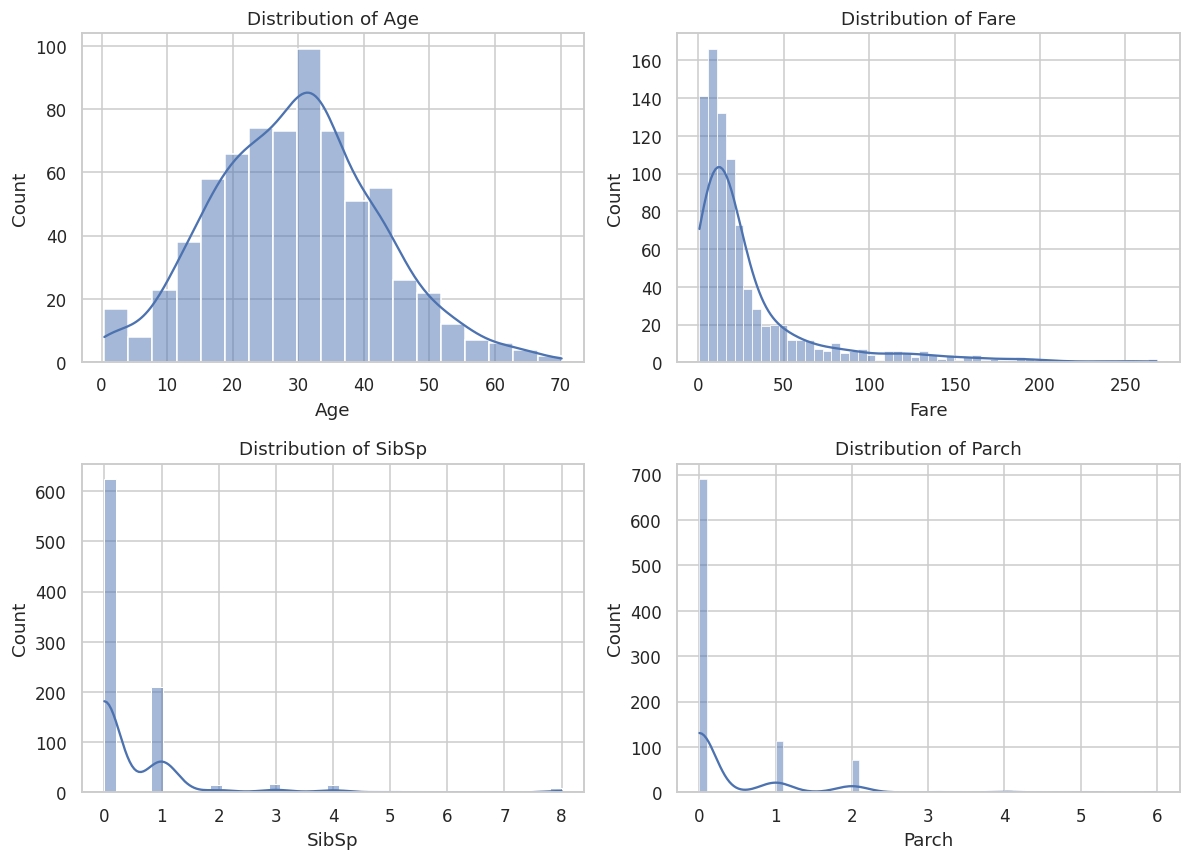

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))num_cols = ['Age', 'Fare', 'SibSp', 'Parch']for ax, col in zip(axes.flat, num_cols):    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#4C72B0')    ax.set_title(f'Distribution of {col}')plt.tight_layout()plt.show()

## 6. Univariate Analysis — Boxplots (Outlier Detection)

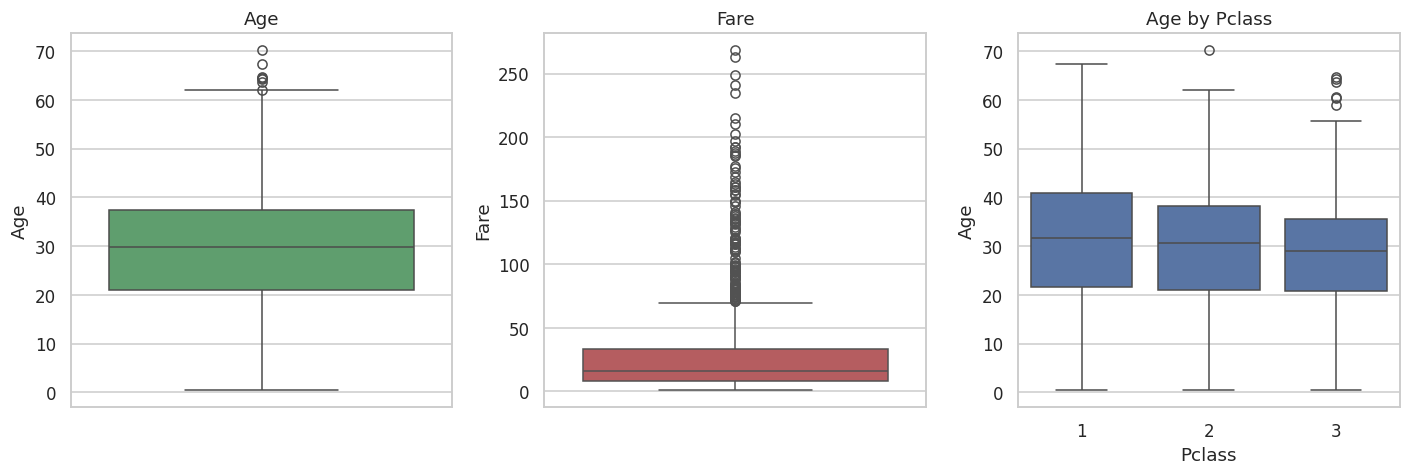

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))sns.boxplot(y=df['Age'], ax=axes[0], color='#55A868'); axes[0].set_title('Age')sns.boxplot(y=df['Fare'], ax=axes[1], color='#C44E52'); axes[1].set_title('Fare')sns.boxplot(x=df['Pclass'], y=df['Age'], ax=axes[2]); axes[2].set_title('Age by Pclass')plt.tight_layout()plt.show()

**Observation:** `Fare` shows many high-value outliers (first-class passengers paying significantly more than the rest). `Age` has a handful of elderly outliers but is otherwise well-behaved. Median age is fairly consistent across classes, though 1st class skews slightly older.

## 7. Correlation Matrix

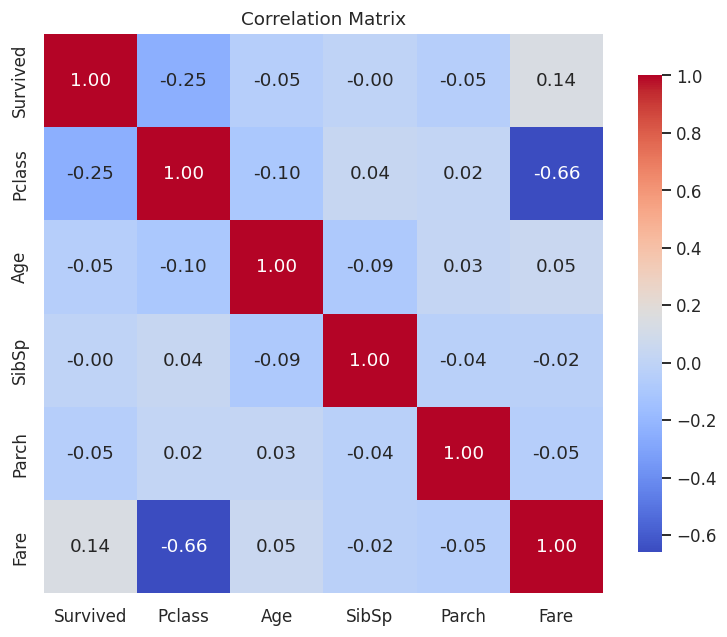

In [10]:
num_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]corr = num_df.corr()plt.figure(figsize=(7, 6))sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={'shrink': 0.8})plt.title('Correlation Matrix')plt.tight_layout()plt.show()

**Observation:** `Pclass` and `Fare` are strongly negatively correlated (≈ -0.66) — lower class number (1 = highest class) pays higher fare, which is expected by definition. `Pclass` is negatively correlated with `Survived` (≈ -0.25), and `Fare` is positively correlated with `Survived` (≈ 0.15), hinting that wealthier passengers in higher classes were more likely to survive. No signs of problematic multicollinearity among the predictors themselves.

## 8. Pairplot — Multivariate Relationships

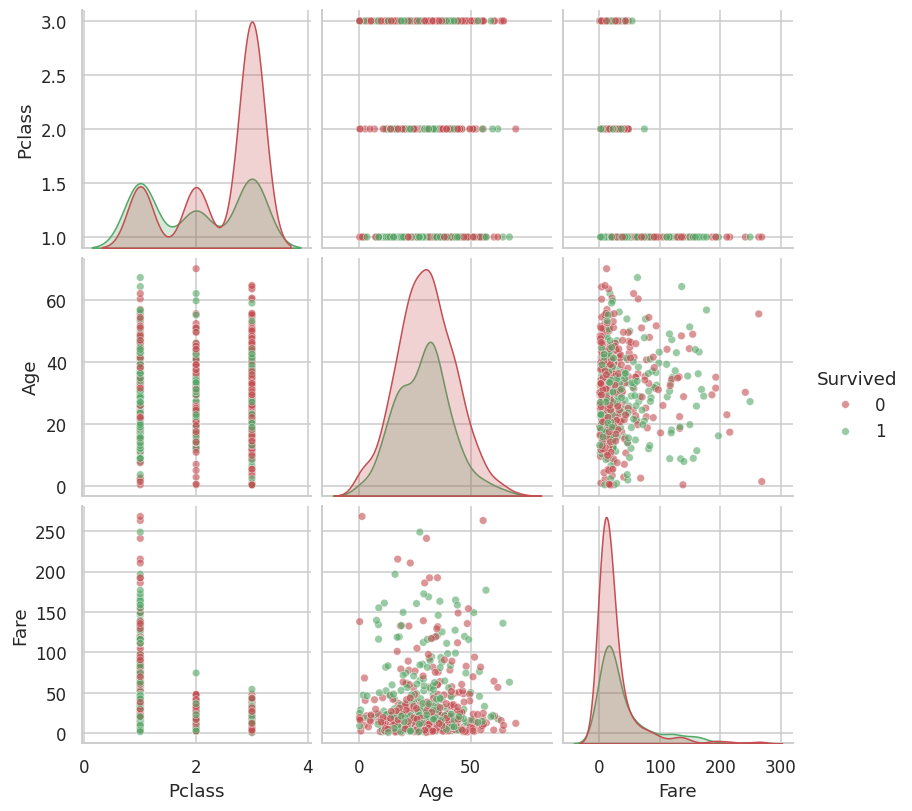

In [11]:
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']].dropna(), hue='Survived',             palette={0: '#C44E52', 1: '#55A868'}, plot_kws={'alpha': 0.6, 's': 25})plt.show()

## 9. Survival Rate by Key Categorical Features

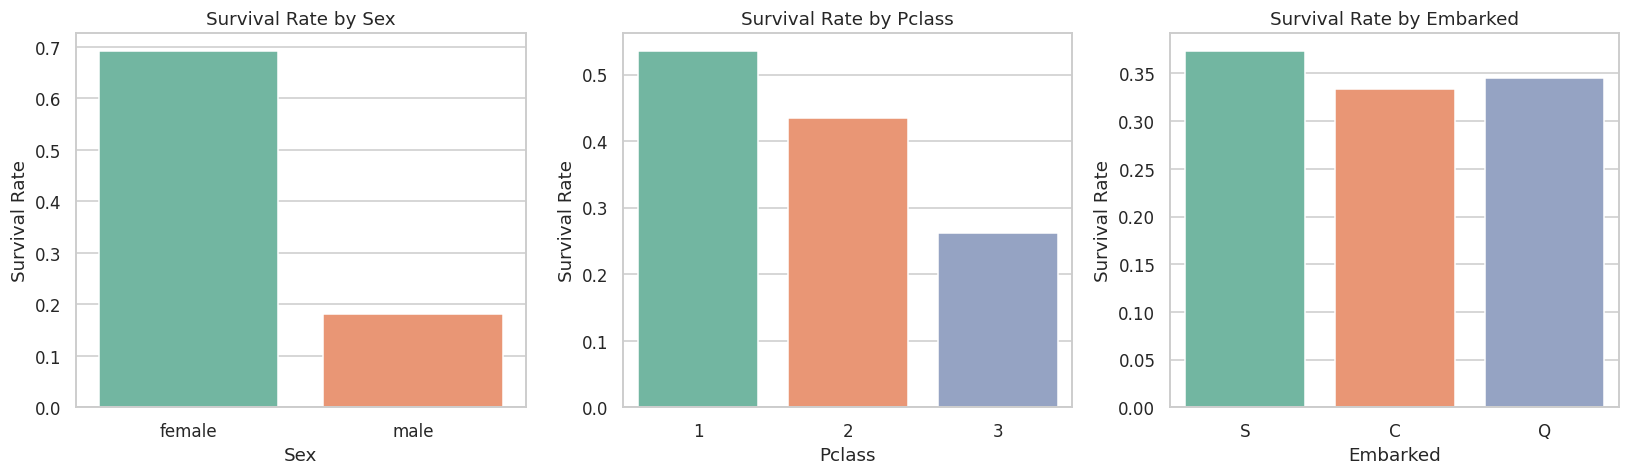

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', legend=False, palette='Set2', errorbar=None, ax=axes[0])axes[0].set_title('Survival Rate by Sex'); axes[0].set_ylabel('Survival Rate')sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', legend=False, palette='Set2', errorbar=None, ax=axes[1])axes[1].set_title('Survival Rate by Pclass'); axes[1].set_ylabel('Survival Rate')sns.barplot(data=df, x='Embarked', y='Survived', hue='Embarked', legend=False, palette='Set2', errorbar=None, ax=axes[2])axes[2].set_title('Survival Rate by Embarked'); axes[2].set_ylabel('Survival Rate')plt.tight_layout()plt.show()

**Observation:** Sex is the single strongest predictor visible in the data — female passengers survived at a much higher rate than male passengers (consistent with the 'women and children first' protocol). Survival rate decreases steadily from 1st to 3rd class. Passengers who embarked at Cherbourg (C) show a somewhat higher survival rate, likely correlated with class composition at that port.

## 10. Age Distribution by Survival Status

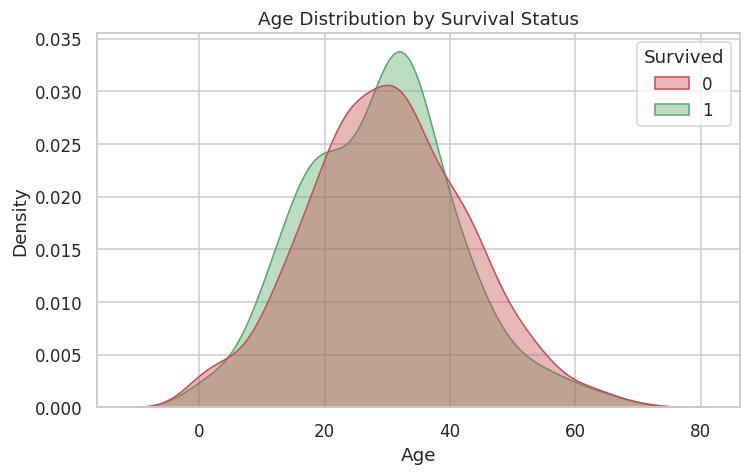

In [13]:
plt.figure(figsize=(7, 4.5))sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, common_norm=False,            palette={0: '#C44E52', 1: '#55A868'}, alpha=0.4)plt.title('Age Distribution by Survival Status')plt.tight_layout()plt.show()

**Observation:** Survivors and non-survivors have broadly similar age distributions, but very young children show a slightly elevated survival density, consistent with priority being given to children during evacuation.

## 11. Fare by Passenger Class

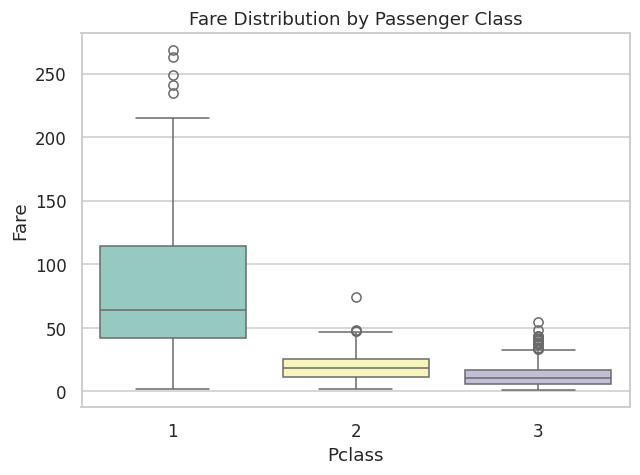

In [14]:
plt.figure(figsize=(6, 4.5))sns.boxplot(data=df, x='Pclass', y='Fare', hue='Pclass', legend=False, palette='Set3')plt.title('Fare Distribution by Passenger Class')plt.tight_layout()plt.show()

## 12. Key Findings / Feature-Level Inferences1. **Sex is the strongest survival signal** in the dataset — being female roughly quadruples the chance of survival compared to being male.2. **Passenger class matters** — 1st class passengers survived at notably higher rates than 3rd class, likely reflecting cabin location, lifeboat access, and crew priority.3. **Fare correlates with survival** (driven mainly by its relationship with class) — higher fares paid by 1st class passengers track with higher survival.4. **Fare and SibSp/Parch are right-skewed**, so models or further analysis should consider log-transforming `Fare` and capping/treating family-size features carefully.5. **Age has a mild influence** — very young children had somewhat better survival odds; otherwise age is not a dominant single predictor.6. **No problematic multicollinearity** between independent numeric predictors — only the expected, definitional relationship between `Pclass` and `Fare`.7. **Missing data strategy:** `Cabin` is too sparse (~77% missing) to use directly without heavy feature engineering (e.g., deck extraction or a 'has_cabin' flag); `Age` can be reasonably imputed using median/group-wise median by `Pclass`/`Sex`; `Embarked` has negligible missingness and can be imputed with the mode.

## 13. Interview Questions — Answers**1. What is the purpose of EDA?**EDA (Exploratory Data Analysis) is the process of investigating a dataset using statistics and visualizations before modeling, in order to understand its structure, spot missing values/outliers, check relationships between variables, and form hypotheses about what's driving the target variable.**2. How do boxplots help in understanding a dataset?**Boxplots summarize a numeric feature's distribution (median, quartiles, spread) in one view and make outliers easy to spot as points beyond the whiskers. They're also useful for comparing a numeric feature's distribution across categories side-by-side (e.g., Age by Pclass).**3. What is correlation and why is it useful?**Correlation measures the strength and direction of the linear relationship between two numeric variables, typically on a scale from -1 to 1. It's useful for spotting which features move together, identifying potential predictors of a target variable, and flagging redundant (highly correlated) features.**4. How do you detect skewness in data?**Skewness can be detected visually with a histogram or KDE plot (an asymmetric tail), or numerically using `.skew()` — values near 0 indicate symmetry, positive values indicate a right (long) tail, and negative values indicate a left tail.**5. What is multicollinearity?**Multicollinearity occurs when two or more independent/predictor variables are highly correlated with each other, making it hard for a model to isolate each variable's individual effect on the target. It's typically detected via a correlation matrix or Variance Inflation Factor (VIF).**6. What tools do you use for EDA?**Pandas for data manipulation and summary statistics, Matplotlib and Seaborn for static visualizations, and Plotly for interactive visualizations. NumPy and SciPy are also commonly used for numeric/statistical operations.**7. Can you explain a time when EDA helped you find a problem?**In this Titanic analysis, EDA revealed that `Cabin` was missing for ~77% of records — without checking this upfront, that column could have been fed into a model with poor or misleading imputation, hurting model quality. EDA also revealed `Fare`'s strong right skew, which would distort distance-based models unless transformed.**8. What is the role of visualization in ML?**Visualization helps build intuition about feature distributions and relationships, communicates findings to stakeholders, guides feature engineering and preprocessing decisions (transformations, encoding, outlier handling), and helps validate model assumptions and diagnose errors after training.